# Credit Score Classification — Leakage-Free, Fully Tuned Pipeline

**Dataset:** [Credit Score Classification](https://www.kaggle.com/datasets/parisrohan/credit-score-classification) by ParisRohan
**Task:** classify a customer-month snapshot into Poor / Standard / Good.
**Hardware:** Kaggle GPU T4 x2.

## Read this first: what this dataset is and isn't

100,000 rows = **12,500 customers x 8 monthly snapshots** (January-August). The target is a
credit-score *bucket*, not a default event — nobody defaults in this data, there is no outcome
and no loss. The dirty values (`_______` occupations, `!@9#%8` payment behaviours, ages of 8698,
trailing underscores on numbers) are **deliberately injected**: this is a synthetic dataset built
as a data-cleaning exercise, and its labels come from a generator rule rather than from observed
customers.

So the honest framing is: this notebook is a **methodology showcase**, not a deployable credit
model. Everything below is engineered to produce a number that survives scrutiny — not to be
pointed at real borrowers.

## What this pipeline does that most public notebooks on this dataset don't

1. **Group-aware splitting** on `Customer_ID`. Each customer appears ~8 times and their label is
   near-constant across those months, so a random row split lets the model memorise the customer.
2. **Preprocessing fit on train only.** Every quantile cap, median and mode is learned from the
   training customers and *applied* to holdout — no global statistics computed over all rows.
3. **Causal time features.** Rolling stats use `shift(1)` before the expanding window, so no row
   ever sees its own present or future.
4. **Model selection on out-of-fold predictions, never on the holdout.** The holdout is scored
   exactly once, at the end, by a model chosen without ever having looked at it.
5. **Ensembling and decision-threshold tuning fit on OOF**, so the gains are earned rather than
   read off the test set.
6. **Explicit leakage audits** that fail loudly rather than passing silently.

**Before running:** add the dataset via **+ Add Input** (search "Credit Score Classification",
ParisRohan). Set **Settings -> Accelerator = GPU T4 x2**.

In [1]:
!nvidia-smi

Sat Aug 15 01:55:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# CatBoost, Optuna and SHAP need explicit installs; LightGBM/XGBoost/sklearn/torch ship with the image.
!pip install -q catboost optuna shap

In [3]:
import os, re, glob, json, math, warnings, random, itertools, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, f1_score, accuracy_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, log_loss)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CLASS_NAMES = ['Poor', 'Standard', 'Good']
TARGET_MAP  = {'Poor': 0, 'Standard': 1, 'Good': 2}

N_GPUS = torch.cuda.device_count()
print(f"PyTorch sees {N_GPUS} GPU(s):")
for i in range(N_GPUS):
    print(f"  cuda:{i} -> {torch.cuda.get_device_name(i)}")

# ----------------------------------------------------------------------------------
# RUN BUDGET -- read this before running.
#
# FAST_MODE=True  : end-to-end in roughly 30-45 min. Use it for the first run to confirm
#                   the whole notebook completes and the numbers are sane.
# FAST_MODE=False : full run, roughly 1.5-2.5 h, bounded by the hard timeouts below.
#
# Every expensive stage is wall-clock capped, so the notebook CANNOT run indefinitely.
# ----------------------------------------------------------------------------------
FAST_MODE = False

if FAST_MODE:
    N_TRIALS, TUNE_TIMEOUT, TUNE_SUBSAMPLE = 8,  300,  0.30   # per study, seconds
    N_EST_MAX, ES_ROUNDS, TUNE_N_FOLDS     = 600, 40,  2
    MLP_EPOCHS, SHAP_SAMPLE                = 25,  500
else:
    N_TRIALS, TUNE_TIMEOUT, TUNE_SUBSAMPLE = 30, 1500, 0.50
    N_EST_MAX, ES_ROUNDS, TUNE_N_FOLDS     = 1500, 60, 2
    MLP_EPOCHS, SHAP_SAMPLE                = 40,  1500

_T0 = time.time(); _LAST = [time.time()]

def section(name):
    '''Progress beacon. A long-running cell with no output is indistinguishable from a hang.'''
    now = time.time()
    print(f"\n{'=' * 72}")
    print(f"[{(now - _T0) / 60:6.1f} min total | +{(now - _LAST[0]) / 60:5.1f} min] {name}")
    print('=' * 72, flush=True)
    _LAST[0] = now

print(f"\nFAST_MODE = {FAST_MODE}  ->  {N_TRIALS} trials/study, "
      f"{TUNE_TIMEOUT}s cap each, {N_EST_MAX} tree ceiling")
print("Set FAST_MODE = False for the full run once this completes cleanly.")

PyTorch sees 2 GPU(s):
  cuda:0 -> Tesla T4
  cuda:1 -> Tesla T4

FAST_MODE = False  ->  30 trials/study, 1500s cap each, 1500 tree ceiling
Set FAST_MODE = False for the full run once this completes cleanly.


In [4]:
def find_csv(name_pattern):
    matches = glob.glob(f"/kaggle/input/**/{name_pattern}", recursive=True)
    if not matches:
        raise FileNotFoundError(
            f"No file matching '{name_pattern}' found under /kaggle/input. "
            f"Did you add the 'Credit Score Classification' dataset via + Add Input?"
        )
    return matches[0]

train_path = find_csv("train.csv")
print("Using train file:", train_path)

df_raw = pd.read_csv(train_path, low_memory=False)
print(df_raw.shape)
df_raw.head()

Using train file: /kaggle/input/datasets/parisrohan/credit-score-classification/train.csv
(100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## Diagnostic: how much independent information is actually here?

Two questions decide the design of everything below, so they get answered with numbers before
anything is modelled:

1. **Is the label constant within a customer?** If a customer's 8 rows share one label, the
   effective sample size is ~12,500, not 100,000 — every target is 8x duplicated. That inflates
   apparent confidence and makes a random row split close to meaningless.
2. **How imbalanced is it?** Drives the class weighting and the choice of macro-F1 as headline
   metric.

Target distribution:
Credit_Score
Standard    0.5317
Poor        0.2900
Good        0.1783
Name: proportion, dtype: float64

Unique customers: 12,500
Rows per customer (mean): 8.00

Distinct labels per customer:
Credit_Score
1    5208
2    7262
3      30
Name: count, dtype: int64

--> 41.7% of customers have a SINGLE label across all their months.
--> Effective independent sample size is nearer 12,500 than 100,000.


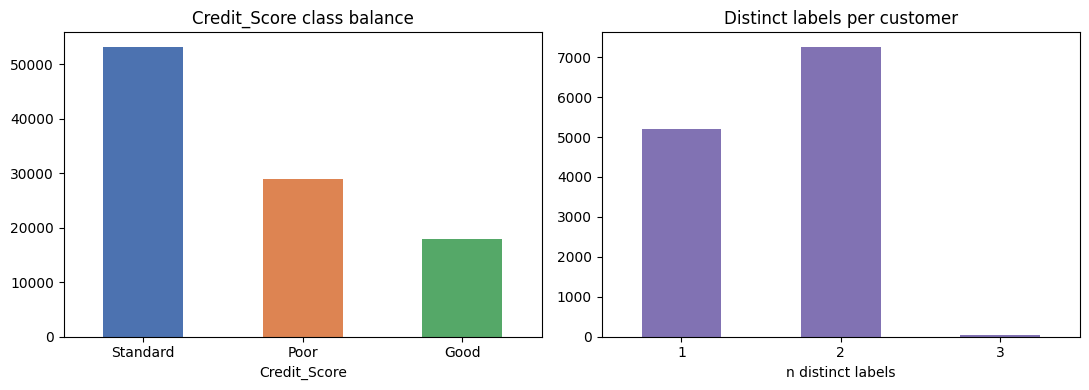

In [5]:
print("Target distribution:")
print(df_raw['Credit_Score'].value_counts(normalize=True).round(4))

n_cust = df_raw['Customer_ID'].nunique()
print(f"\nUnique customers: {n_cust:,}")
print(f"Rows per customer (mean): {df_raw.groupby('Customer_ID').size().mean():.2f}")

label_nunique = df_raw.groupby('Customer_ID')['Credit_Score'].nunique()
print("\nDistinct labels per customer:")
print(label_nunique.value_counts().sort_index())
const_frac = (label_nunique == 1).mean()
print(f"\n--> {const_frac:.1%} of customers have a SINGLE label across all their months.")
print(f"--> Effective independent sample size is nearer {n_cust:,} than {len(df_raw):,}.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_raw['Credit_Score'].value_counts().plot(kind='bar', ax=axes[0],
                                           color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title("Credit_Score class balance"); axes[0].tick_params(axis='x', rotation=0)
label_nunique.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#8172B3')
axes[1].set_title("Distinct labels per customer"); axes[1].set_xlabel("n distinct labels")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Split first, preprocess second

This ordering is the point. If you clean and impute the full frame and *then* split, every median,
mode and quantile cap you computed has already seen the holdout customers. The effect is small —
well under a point of macro-F1 — but it quietly contradicts the whole premise, and it is the first
thing a reviewer checks.

So the raw frame is split on `Customer_ID` **before any transformation touches it**. All fitted
statistics come from the training customers only.

Per-customer operations (forward/backward fill within a customer's own history, `shift(1)`
expanding windows) are safe to run on either side independently, precisely because a customer never
spans the split.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, ho_idx = next(gss.split(df_raw, df_raw['Credit_Score'], groups=df_raw['Customer_ID']))

raw_train   = df_raw.iloc[tr_idx].reset_index(drop=True)
raw_holdout = df_raw.iloc[ho_idx].reset_index(drop=True)

assert set(raw_train['Customer_ID']).isdisjoint(set(raw_holdout['Customer_ID'])), "Customer leakage!"
print(f"Raw train:   {raw_train.shape}  ({raw_train['Customer_ID'].nunique():,} customers)")
print(f"Raw holdout: {raw_holdout.shape}  ({raw_holdout['Customer_ID'].nunique():,} customers)")
print("No customer overlap — confirmed.")

Raw train:   (80000, 28)  (10,000 customers)
Raw holdout: (20000, 28)  (2,500 customers)
No customer overlap — confirmed.


## Cleaning

Several numeric columns arrive as strings padded with junk. The cleaner strips everything except
digits, `.` and `-`, then coerces — but **only for object-dtype columns**. Running the same string
surgery on a column that already parsed as float would mangle anything in scientific notation
(`1.23e-05` -> `1.2305`), so genuine numeric columns get a plain `to_numeric` instead.

Impossible values become `NaN` rather than being clipped, so the imputation stage can make a better
guess from the customer's own history. The two quantile caps are **fitted on train** and passed to
holdout as constants.

In [7]:
NUMERIC_COLS_TO_CLEAN = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly',
    'Monthly_Balance', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
    'Num_Credit_Inquiries', 'Total_EMI_per_month', 'Monthly_Inhand_Salary',
    'Credit_Utilization_Ratio', 'Delay_from_due_date',
]

CATEGORICAL_COLS = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']

MONTH_ORDER = {m: i for i, m in enumerate(
    ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
     'September', 'October', 'November', 'December'], start=1)}


def clean_numeric(series):
    '''Strip junk characters from a string-typed numeric column and coerce to float.'''
    cleaned = (series.astype(str)
                     .str.replace(r'[^0-9.\-]', '', regex=True)
                     .replace('', np.nan)
                     .replace('-', np.nan))
    return pd.to_numeric(cleaned, errors='coerce')


def parse_credit_history_age(series):
    '''"22 Years and 1 Months" -> 265. Also handles years-only and months-only strings.'''
    def parse_one(x):
        if pd.isna(x):
            return np.nan
        s = str(x)
        y = re.search(r'(\d+)\s*Year', s)
        m = re.search(r'(\d+)\s*Month', s)
        if y is None and m is None:
            return np.nan
        return (int(y.group(1)) * 12 if y else 0) + (int(m.group(1)) if m else 0)
    return series.apply(parse_one)


def basic_clean(df):
    '''Stateless: type coercion, sentinel removal, month parsing. No fitted statistics.'''
    df = df.copy()

    for col in NUMERIC_COLS_TO_CLEAN:
        if col not in df.columns:
            continue
        if df[col].dtype == object:
            df[col] = clean_numeric(df[col])
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['Occupation']        = df['Occupation'].replace('_______', np.nan)
    df['Credit_Mix']        = df['Credit_Mix'].replace('_', np.nan)
    df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

    df['Credit_History_Age_Months'] = parse_credit_history_age(df['Credit_History_Age'])
    df['Month_Num'] = df['Month'].map(MONTH_ORDER)
    return df


def apply_outlier_rules(df, stats):
    '''Impossible / extreme values -> NaN. Quantile caps come from the fitted `stats`.'''
    df = df.copy()
    df.loc[(df['Age'] < 14) | (df['Age'] > 100), 'Age'] = np.nan
    df.loc[df['Annual_Income'] > stats['income_cap'], 'Annual_Income'] = np.nan
    df.loc[df['Total_EMI_per_month'] > stats['emi_cap'], 'Total_EMI_per_month'] = np.nan
    df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan
    df.loc[df['Num_Credit_Card'] > 20, 'Num_Credit_Card'] = np.nan
    df.loc[df['Interest_Rate'] > 40, 'Interest_Rate'] = np.nan
    df.loc[(df['Num_of_Loan'] < 0) | (df['Num_of_Loan'] > 15), 'Num_of_Loan'] = np.nan
    df.loc[(df['Num_of_Delayed_Payment'] < 0) | (df['Num_of_Delayed_Payment'] > 30),
           'Num_of_Delayed_Payment'] = np.nan
    df.loc[df['Num_Credit_Inquiries'] > 50, 'Num_Credit_Inquiries'] = np.nan
    return df

## Imputation: the customer's own history before the population's

Falling back to a population median is the *last* resort, not the first. Columns are handled in
three tiers depending on how they behave over a customer's timeline:

**Tier 0 — exact reconstruction.** `Credit_History_Age` increments by exactly one month per calendar
month, so `value - Month_Num` is a **constant** within a customer. Take the median of that constant
over the rows where it *is* observed, add the month back, and every missing value is recovered
exactly — no approximation. Median-filling this column, as the first version did, destroys one of
the strongest predictors in the dataset.

**Tier 1 — carry forward/backward** (`PANEL_COLS`). Occupation, income, credit mix and similar
barely move month to month, so the customer's own observed value is the right answer. This tier does
the heavy lifting: on the full dataset it resolves roughly 54,000 missing values, including 16,180
in `Credit_Mix` — about 20% of all rows in a top-ranked predictor.

**Tier 2 — interpolate along the timeline** (`PANEL_INTERP_COLS`). Balances, delayed-payment counts
and credit-limit changes genuinely vary month to month, so copying a neighbouring value is wrong —
but the population median is far worse. Interpolating between the customer's own observed months is
the honest middle. Without this tier, ~13,000 values in `Num_of_Delayed_Payment`,
`Amount_invested_monthly`, `Changed_Credit_Limit` and `Monthly_Balance` would drop straight through
to a global median that knows nothing about the customer.

**Tier 3 — train-fitted median/mode**, for customers whose value is missing in *every* month and
where nothing better exists.

In [8]:
# Portfolio regime (True): a customer's full history window is on file, so imputation and
# features may look across all of their months. Cold-start regime (False): only the past may
# be used. This one flag governs both the imputation below and the window features later.
USE_FULL_WINDOW = True

# Tier 1 -- attributes that should barely move month to month for the same person.
# Carrying the last/next observed value forward is the right call.
PANEL_COLS = ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
              'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
              'Num_of_Loan', 'Credit_Mix', 'Payment_Behaviour',
              'Payment_of_Min_Amount', 'Num_Credit_Inquiries']

# Tier 2 -- genuinely time-varying, so copying a neighbouring month is wrong, but the
# population median is far worse. Interpolate along the customer's own timeline instead.
PANEL_INTERP_COLS = ['Num_of_Delayed_Payment', 'Amount_invested_monthly',
                     'Changed_Credit_Limit', 'Monthly_Balance', 'Outstanding_Debt',
                     'Delay_from_due_date', 'Credit_Utilization_Ratio',
                     'Total_EMI_per_month']


def reconstruct_credit_history(df):
    '''`Credit_History_Age_Months - Month_Num` is constant within a customer -> exact recovery.'''
    df = df.copy()
    anchor = (df['Credit_History_Age_Months'] - df['Month_Num'])
    anchor = anchor.groupby(df['Customer_ID']).transform('median')
    df['Credit_History_Age_Months'] = df['Credit_History_Age_Months'].fillna(anchor + df['Month_Num'])
    df.loc[df['Credit_History_Age_Months'] < 0, 'Credit_History_Age_Months'] = np.nan
    return df


def panel_fill(df):
    '''Fill within each customer's own timeline first. Uses no population statistics.'''
    df = df.sort_values(['Customer_ID', 'Month_Num']).reset_index(drop=True)
    df = reconstruct_credit_history(df)

    # Tier 1: carry the customer's own observed value across their months.
    for col in PANEL_COLS:
        if col in df.columns:
            df[col] = df.groupby('Customer_ID')[col].transform(lambda s: s.ffill().bfill())

    # Tier 2: interpolate along the customer's timeline. Rows are already month-ordered, so
    # this is a temporally sensible estimate rather than a copied neighbour.
    # `interpolate` looks both ways, which is a portfolio-regime assumption -- under the strict
    # cold-start setting we may only carry the past forward.
    for col in PANEL_INTERP_COLS:
        if col in df.columns:
            g = df.groupby('Customer_ID')[col]
            if USE_FULL_WINDOW:
                df[col] = g.transform(
                    lambda s: s.interpolate(limit_direction='both')).astype(float)
            else:
                df[col] = g.transform(lambda s: s.ffill())
    return df


def global_fill(df, stats):
    '''Whatever a customer's own history could not supply, fall back to TRAIN statistics.'''
    df = df.copy()
    for col, val in stats['medians'].items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    for col, val in stats['modes'].items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

## Feature engineering: exploit the panel structure, respect causality

Four families of features:

- **Same-month ratios** — debt-to-income, EMI-to-income, loans-per-account. The customer's state
  *this* month.
- **Loan-type flags** — `Type_of_Loan` is a comma-separated list, and *which* products a customer
  holds matters enormously: a payday loan is not a home-equity loan. The previous version extracted
  only a count and threw the column away. Multi-hot encoding recovers that signal.
- **Causal rolling stats** — mean/std of key risk indicators over the customer's *previous* months
  only (`shift(1)` before the expanding window). The first month of a customer has no history, so
  those features are `NaN` and get filled with 0 rather than leaking the current value back in.
- **Trajectory features** — `value - historical_mean` and month-over-month `diff`. A customer whose
  delinquency is *rising* is a different risk from one sitting at the same level, and the level
  alone cannot express that.

- **Full-window customer aggregates** (`USE_FULL_WINDOW`) — mean/std/min/max/range of key columns
  across *all* of a customer's months, plus each row's deviation from its own customer mean. These
  look forward as well as backward, so they belong to the **portfolio regime**: valid when you hold
  a complete history window on file, invalid for a cold-start decision on someone seen once. They
  are still entirely label-free — no target information is used, only features. Set the flag to
  `False` and re-run to get the strict cold-start feature set.

`Month_Num` is deliberately **not** kept as a model feature. It only ever takes values 1-8, so tree
splits on it encode calendar position that cannot generalise to a ninth month. It is replaced by
`months_of_history`, which is what the model actually needs to know.

> **Why this section grew.** The first run of this pipeline landed every model family — linear,
> bagged trees, three boosters, a neural net — inside 0.006 macro-F1 of each other, and Optuna
> tuning moved the score by +0.002. That pattern means the models were saturated: the binding
> constraint was the *feature set*, not the algorithm or its hyperparameters. Extra capacity had
> nothing left to extract, so the work moved here.

In [9]:
LOAN_TYPES = ['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan',
              'Mortgage Loan', 'Student Loan', 'Debt Consolidation Loan', 'Payday Loan']

ROLL_COLS = ['Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt',
             'Credit_Utilization_Ratio', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
             'Monthly_Balance']

# Full-window aggregates summarise a customer across ALL their months.
# Governed by USE_FULL_WINDOW, set alongside the imputation tiers above.
WINDOW_COLS = ['Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt',
               'Credit_Utilization_Ratio', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
               'Interest_Rate', 'Credit_Mix_ord', 'Monthly_Balance']


def loan_type_features(df):
    '''Multi-hot the comma-separated Type_of_Loan list, plus a distinct-type count.'''
    df = df.copy()
    s = df['Type_of_Loan'].fillna('').astype(str)
    for lt in LOAN_TYPES:
        col = 'Loan_' + lt.replace(' ', '_').replace('-', '_')
        df[col] = s.str.contains(re.escape(lt), case=False, regex=True).astype(np.int8)

    def count_types(x):
        x = x.strip()
        if x in ('', 'nan', 'Not Specified'):
            return 0
        parts = re.split(r',\s*and\s+|,\s*|\s+and\s+', x)
        return len([p for p in parts if p.strip() and p.strip() != 'Not Specified'])

    df['Num_Loan_Types'] = s.apply(count_types).astype(np.int16)
    return df


def build_features(df):
    '''All stateless or strictly within-customer. Safe to run per split side.'''
    df = df.sort_values(['Customer_ID', 'Month_Num']).reset_index(drop=True)

    # --- same-month ratios ---
    df['Debt_to_Income']       = df['Outstanding_Debt'] / (df['Annual_Income'] + 1)
    df['EMI_to_Income']        = (df['Total_EMI_per_month'] * 12) / (df['Annual_Income'] + 1)
    df['Investment_to_Income'] = (df['Amount_invested_monthly'] * 12) / (df['Annual_Income'] + 1)
    df['Loan_per_Account']     = df['Num_of_Loan'] / (df['Num_Bank_Accounts'] + 1)
    df['Debt_per_Loan']        = df['Outstanding_Debt'] / (df['Num_of_Loan'] + 1)
    df['Salary_Ratio']         = df['Monthly_Inhand_Salary'] * 12 / (df['Annual_Income'] + 1)
    df['Delay_per_Loan']       = df['Num_of_Delayed_Payment'] / (df['Num_of_Loan'] + 1)
    df['Credit_Age_per_Year']  = df['Credit_History_Age_Months'] / (df['Age'] * 12 + 1)

    df = loan_type_features(df)

    # numeric view of Credit_Mix, so it can be aggregated across a customer's window below
    df['Credit_Mix_ord'] = df['Credit_Mix'].map({'Bad': 0, 'Standard': 1, 'Good': 2}).fillna(1)

    # --- how much history does this row actually have behind it? ---
    df['months_of_history'] = df.groupby('Customer_ID').cumcount().astype(np.int16)

    # --- causal rolling stats: shift(1) BEFORE expanding, so no row sees its own present ---
    g = df.groupby('Customer_ID')
    for col in ROLL_COLS:
        hist_mean = g[col].transform(lambda s: s.shift(1).expanding().mean())
        hist_std  = g[col].transform(lambda s: s.shift(1).expanding().std())
        hist_max  = g[col].transform(lambda s: s.shift(1).expanding().max())
        # trajectory: computed BEFORE the NaN->0 fill, so month 1 stays NaN instead of
        # becoming a spurious "delta equal to the raw level"
        df[f'{col}_hist_mean']  = hist_mean
        df[f'{col}_hist_std']   = hist_std
        df[f'{col}_hist_max']   = hist_max
        df[f'{col}_delta_mean'] = df[col] - hist_mean
        df[f'{col}_diff']       = g[col].diff()

    hist_cols = [c for c in df.columns
                 if c.endswith(('_hist_mean', '_hist_std', '_hist_max', '_delta_mean', '_diff'))]
    df[hist_cols] = df[hist_cols].fillna(0)

    # --- full-window customer aggregates (PORTFOLIO REGIME ONLY) ---
    # These look across ALL of a customer's months, including later ones. That is legitimate
    # when you hold a complete history window on file, and invalid for a cold-start decision.
    # Still label-free -- no target information is involved, only features.
    if USE_FULL_WINDOW:
        for col in WINDOW_COLS:
            gc = df.groupby('Customer_ID')[col]
            df[f'{col}_cust_mean'] = gc.transform('mean')
            df[f'{col}_cust_std']  = gc.transform('std')
            df[f'{col}_cust_min']  = gc.transform('min')
            df[f'{col}_cust_max']  = gc.transform('max')
            df[f'{col}_cust_rng']  = df[f'{col}_cust_max'] - df[f'{col}_cust_min']
            df[f'{col}_vs_cust']   = df[col] - df[f'{col}_cust_mean']

    df = df.replace([np.inf, -np.inf], np.nan)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(0)
    return df

## Two encodings, on purpose

LightGBM, XGBoost, logistic regression and the neural net get a **one-hot** frame. CatBoost gets the
**raw categorical columns** instead, via `cat_features`.

That distinction matters: CatBoost's entire competitive advantage is ordered target statistics on
native categoricals. Handing it a pre-one-hotted matrix — as the previous version did — throws that
away and reduces it to a slower LightGBM.

Holdout columns are reindexed against the training column list, so a category that only appears in
holdout can never silently add a column or shift the feature order.

In [10]:
DROP_COLS = ['ID', 'Name', 'SSN', 'Month', 'Credit_History_Age', 'Type_of_Loan',
             'Month_Num', 'Credit_Score', 'Customer_ID']

ORDINAL_MAPS = {
    'Credit_Mix':            ({'Bad': 0, 'Standard': 1, 'Good': 2}, 1),
    'Payment_of_Min_Amount': ({'No': 0, 'Yes': 1, 'NM': 0.5}, 0.5),
}
CAT_FEATURES = ['Occupation', 'Payment_Behaviour']


def encode(df_fe, ohe_columns=None, cat_columns=None):
    '''Returns (X_ohe, X_cat, y, groups). Pass the train column lists to align holdout.'''
    df = df_fe.copy()
    for col, (mapping, default) in ORDINAL_MAPS.items():
        df[col] = df[col].map(mapping).fillna(default).astype(float)

    y      = df['Credit_Score'].map(TARGET_MAP).astype(int)
    groups = df['Customer_ID'].copy()

    base = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # CatBoost frame: keep the categoricals as strings
    X_cat = base.copy()
    for c in CAT_FEATURES:
        X_cat[c] = X_cat[c].astype(str)
    if cat_columns is not None:
        X_cat = X_cat.reindex(columns=cat_columns)
        for c in CAT_FEATURES:
            X_cat[c] = X_cat[c].fillna('Unknown').astype(str)
        X_cat = X_cat.fillna(0)

    # One-hot frame for everything else
    X_ohe = pd.get_dummies(base, columns=CAT_FEATURES, drop_first=True)
    if ohe_columns is not None:
        X_ohe = X_ohe.reindex(columns=ohe_columns, fill_value=0)
    X_ohe = X_ohe.astype(np.float32)

    return X_ohe, X_cat, y, groups

## Run the pipeline — fitting on train, applying to holdout

In [11]:
def fit_transform_train(raw):
    stats = {}
    df = basic_clean(raw)
    stats['income_cap'] = df['Annual_Income'].quantile(0.999)
    stats['emi_cap']    = df['Total_EMI_per_month'].quantile(0.999)

    df = apply_outlier_rules(df, stats)
    df = panel_fill(df)

    num_cols = df.select_dtypes(include=[np.number]).columns
    stats['medians'] = df[num_cols].median().to_dict()
    stats['modes']   = {c: df[c].mode()[0] for c in CATEGORICAL_COLS if c in df.columns}

    df = global_fill(df, stats)
    return build_features(df), stats


def transform(raw, stats):
    df = basic_clean(raw)
    df = apply_outlier_rules(df, stats)
    df = panel_fill(df)
    df = global_fill(df, stats)
    return build_features(df)


fe_train, STATS = fit_transform_train(raw_train)
fe_holdout      = transform(raw_holdout, STATS)

X_train, Xc_train, y_train, groups_train = encode(fe_train)
OHE_COLUMNS, CAT_COLUMNS = list(X_train.columns), list(Xc_train.columns)
X_holdout, Xc_holdout, y_holdout, groups_holdout = encode(fe_holdout, OHE_COLUMNS, CAT_COLUMNS)

print(f"Train  : {X_train.shape}   Holdout: {X_holdout.shape}")
print(f"Features: {X_train.shape[1]} (one-hot frame), {Xc_train.shape[1]} (CatBoost frame)")
print(f"Income cap fitted on train: {STATS['income_cap']:,.0f}")

Train  : (80000, 146)   Holdout: (20000, 146)
Features: 146 (one-hot frame), 129 (CatBoost frame)
Income cap fitted on train: 21,772,343


## Leakage audits

Four checks, written as asserts so a regression stops the notebook rather than quietly degrading a
number. This is the section worth pointing at in an interview: the claim isn't "we were careful",
it's "here is the executable proof".

In [12]:
# 1. No customer appears on both sides.
assert set(groups_train).isdisjoint(set(groups_holdout)), "AUDIT FAIL: customer overlap"

# 2. Feature matrices agree in shape and column order.
assert list(X_train.columns) == list(X_holdout.columns), "AUDIT FAIL: column mismatch"

# 3. Every causal feature is zero on a customer's first observed month — a nonzero value there
#    would mean history was borrowed from the present or the future.
first_rows = fe_train.groupby('Customer_ID').head(1)
for col in ROLL_COLS:
    bad = (first_rows[f'{col}_hist_mean'] != 0).sum()
    assert bad == 0, f"AUDIT FAIL: {col}_hist_mean nonzero on {bad} first-month rows"

# 4. Holdout was transformed with train-fitted constants only.
assert STATS['income_cap'] == basic_clean(raw_train)['Annual_Income'].quantile(0.999), \
    "AUDIT FAIL: income cap not fitted on train alone"

print("All four leakage audits passed.")
print(f"NaNs remaining -> train: {X_train.isna().sum().sum()}, holdout: {X_holdout.isna().sum().sum()}")

All four leakage audits passed.
NaNs remaining -> train: 0, holdout: 0


## Where did the empty cells go?

Missing data in this dataset arrives in three different disguises, and they are **not** the same
problem:

| Disguise | Example | Why it's missing |
|---|---|---|
| Genuinely blank | `Monthly_Inhand_Salary` is `NaN` on ~15% of rows | never recorded |
| Junk sentinel | `Occupation = '_______'`, `Payment_Behaviour = '!@9#%8'`, `Changed_Credit_Limit = '_'` | recorded as a placeholder |
| Impossible value | `Age = 8698`, `Num_Bank_Accounts = -1` | recorded, but wrong |

The third category is the one people get wrong. An age of 8698 is **worse than no age at all** — a
tree will happily split on it and learn nonsense. So the pipeline deliberately *converts* those into
`NaN` (`apply_outlier_rules`) and then imputes them, rather than leaving them or clipping them to a
boundary they never actually sat near.

Everything then flows through a four-stage cascade, cheapest and most-informative source first:

1. **Exact reconstruction** where the panel structure allows it — `Credit_History_Age` is recovered
   losslessly from the customer's own anchor, not guessed.
2. **The customer's own history** — forward/backward fill across their eight months. Someone's own
   January income is a far better estimate of their missing March income than the population median.
3. **Train-fitted median / mode** for whatever survives, e.g. a customer whose value is missing in
   *every* month.
4. **Structural zeros** for the causal history features. A customer's first month genuinely has no
   prior history — that's a real state, not a missing measurement. Filling it with the population
   median would tell the model this person has *average* history when they have none.

The cell below counts what each stage resolves, so the claim is auditable rather than asserted.

In [13]:
def nan_report(raw):
    stages = {}
    df = basic_clean(raw)
    stages['1. after parsing junk strings'] = df.isna().sum()
    df = apply_outlier_rules(df, STATS)
    stages['2. after impossible -> NaN']    = df.isna().sum()
    df = panel_fill(df)
    stages['3. after per-customer fill']    = df.isna().sum()
    df = global_fill(df, STATS)
    stages['4. after train median/mode']    = df.isna().sum()
    rep = pd.DataFrame(stages)
    return rep[rep.sum(axis=1) > 0].sort_values('1. after parsing junk strings', ascending=False)


print("Missing values remaining after each stage (train):")
display(nan_report(raw_train))
print(f"\nRaw '_______' / '_' / '!@9#%8' sentinels in the original file: "
      f"{(raw_train['Occupation'].eq('_______') | raw_train['Credit_Mix'].eq('_') | raw_train['Payment_Behaviour'].eq('!@9#%8')).sum():,} rows")
print(f"Impossible ages converted to NaN: "
      f"{(~basic_clean(raw_train)['Age'].between(14, 100)).sum():,} rows")
print(f"\nFinal NaN count in the model matrices -> "
      f"train: {X_train.isna().sum().sum()}, holdout: {X_holdout.isna().sum().sum()}")

Missing values remaining after each stage (train):


,1. after parsing junk strings,2. after impossible -> NaN,3. after per-customer fill,4. after train median/mode
Credit_Mix,16180,16180,0,0
Monthly_Inhand_Salary,12033,12033,0,0
Type_of_Loan,9184,9184,9184,9184
Name,7929,7929,7929,7929
Credit_History_Age_Months,7149,7149,0,0
Credit_History_Age,7149,7149,7149,7149
Payment_Behaviour,6121,6121,0,0
Occupation,5645,5645,0,0
Num_of_Delayed_Payment,5638,6753,0,0
Amount_invested_monthly,3581,3581,0,0



Raw '_______' / '_' / '!@9#%8' sentinels in the original file: 25,265 rows
Impossible ages converted to NaN: 2,169 rows

Final NaN count in the model matrices -> train: 0, holdout: 0


In [14]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
sample_weight_train = y_train.map(class_weight_dict).values.astype(np.float32)
print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_dict.items()})

cv = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
          .split(X_train, y_train, groups=groups_train))

print("\nFold class balance (StratifiedGroupKFold keeps these even; plain GroupKFold does not):")
for i, (_, va) in enumerate(cv):
    print(f"  fold {i}: n={len(va):6,}  " +
          "  ".join(f"{CLASS_NAMES[c]}={ (y_train.iloc[va]==c).mean():.3f}" for c in classes))

Class weights: {'Poor': np.float64(1.146), 'Standard': np.float64(0.626), 'Good': np.float64(1.887)}

Fold class balance (StratifiedGroupKFold keeps these even; plain GroupKFold does not):
  fold 0: n=16,000  Poor=0.294  Standard=0.529  Good=0.177
  fold 1: n=15,992  Poor=0.285  Standard=0.546  Good=0.170
  fold 2: n=16,000  Poor=0.287  Standard=0.529  Good=0.184
  fold 3: n=16,008  Poor=0.295  Standard=0.532  Good=0.174
  fold 4: n=16,000  Poor=0.294  Standard=0.527  Good=0.179


## The evaluation harness

Every model goes through the same function: train on 5 stratified group folds, collect
**out-of-fold probabilities** on train and **fold-averaged probabilities** on the holdout.

That single structure buys four things at once:
- an honest score for model selection that never touches the holdout;
- OOF probabilities, which are the raw material for ensembling and threshold tuning;
- a 5-model bag for holdout prediction, which is slightly stronger and more stable than one model
  refit on everything;
- somewhere for early stopping to live — each fold stops on its own validation split.

One caveat stated openly: because each fold early-stops on the same rows it is then scored on, the
OOF number carries a small optimistic bias. It is used for *ranking* models, which is what it is
good for. The unbiased number is the holdout, and that gets touched exactly once.

Metrics tracked: macro-F1 (headline, chosen because the classes are imbalanced and all three
matter), weighted-F1, accuracy, macro one-vs-rest ROC-AUC, and log-loss.

In [15]:
def compute_metrics(y_true, proba, mults=None):
    p = proba if mults is None else proba * np.asarray(mults)
    pred = p.argmax(axis=1)
    return {
        'macro_f1':    f1_score(y_true, pred, average='macro'),
        'weighted_f1': f1_score(y_true, pred, average='weighted'),
        'accuracy':    accuracy_score(y_true, pred),
        'roc_auc_ovr': roc_auc_score(y_true, proba, multi_class='ovr', average='macro'),
        'log_loss':    log_loss(y_true, np.clip(proba, 1e-9, 1)),
    }


REG = {}   # name -> {'oof': (n_train, 3), 'holdout': (n_holdout, 3), 'models': [...]}


def run_cv(name, fit_fold, X, y, X_ho, cv=None, verbose=True):
    '''fit_fold(X_tr, y_tr, X_va, y_va, X_ho) -> (model, proba_va, proba_ho)'''
    cv = cv if cv is not None else globals()['cv']
    oof = np.zeros((len(X), 3), dtype=np.float64)
    ho  = np.zeros((len(X_ho), 3), dtype=np.float64)
    models, t0 = [], time.time()

    for k, (i_tr, i_va) in enumerate(cv):
        model, p_va, p_ho = fit_fold(X.iloc[i_tr], y.iloc[i_tr],
                                     X.iloc[i_va], y.iloc[i_va], X_ho)
        oof[i_va] = p_va
        ho += p_ho / len(cv)
        models.append(model)
        if verbose:
            print(f"  fold {k}: macro-F1 = {f1_score(y.iloc[i_va], p_va.argmax(1), average='macro'):.4f}")

    REG[name] = {'oof': oof, 'holdout': ho, 'models': models}
    m = compute_metrics(y, oof)
    if verbose:
        print(f"{name:22s} OOF macro-F1 = {m['macro_f1']:.4f} | "
              f"AUC = {m['roc_auc_ovr']:.4f} | acc = {m['accuracy']:.4f} | "
              f"{time.time()-t0:.0f}s")
    return m


def oof_table():
    rows = {n: compute_metrics(y_train, d['oof']) for n, d in REG.items()}
    return pd.DataFrame(rows).T.sort_values('macro_f1', ascending=False)

## GPU availability probes

Kaggle's pip-installed LightGBM is frequently **not** compiled with GPU support, and XGBoost's
`device='cuda'` path can fail depending on the image. Rather than discovering that halfway through a
40-trial Optuna study, each library gets a two-second probe fit up front and the result drives every
subsequent call. Failing fast beats failing at minute thirty.

In [16]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

_Xp = X_train.head(200); _yp = y_train.head(200)
_Xpc = Xc_train.head(200)


def _probe(label, fn):
    try:
        fn(); print(f"  {label:10s} GPU: available"); return True
    except Exception as e:
        print(f"  {label:10s} GPU: unavailable -> CPU ({str(e)[:70]})"); return False


print("Probing GPU backends...")
LGB_GPU = _probe("LightGBM", lambda: lgb.LGBMClassifier(
    n_estimators=5, device_type='gpu', gpu_platform_id=0, gpu_device_id=0,
    verbosity=-1).fit(_Xp, _yp))
XGB_GPU = _probe("XGBoost", lambda: xgb.XGBClassifier(
    n_estimators=5, tree_method='hist', device='cuda', verbosity=0).fit(_Xp, _yp))
CAT_GPU = _probe("CatBoost", lambda: CatBoostClassifier(
    iterations=5, task_type='GPU', devices='0', verbose=False).fit(
    _Xpc, _yp, cat_features=CAT_FEATURES))

print(f"\nUsing -> LightGBM: {'GPU' if LGB_GPU else 'CPU'} | "
      f"XGBoost: {'GPU' if XGB_GPU else 'CPU'} | CatBoost: {'GPU' if CAT_GPU else 'CPU'}")

Probing GPU backends...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  LightGBM   GPU: available
  XGBoost    GPU: available
  CatBoost   GPU: available

Using -> LightGBM: GPU | XGBoost: GPU | CatBoost: GPU


## Baselines

A linear model and a bagged-tree model, so the gradient-boosting numbers later have something to be
measured against. Both get `class_weight='balanced'`, same as everything else.

In [17]:
scaler = StandardScaler().fit(X_train)
X_train_s   = scaler.transform(X_train)
X_holdout_s = scaler.transform(X_holdout)


def fit_logreg(X_tr, y_tr, X_va, y_va, X_ho):
    sc = StandardScaler().fit(X_tr)
    # tol is loosened deliberately: this is a reference point, not a contender, and lbfgs
    # on 64k x 135 will otherwise grind for minutes per fold chasing digits nobody reads.
    m = LogisticRegression(max_iter=400, tol=1e-3, class_weight='balanced', random_state=SEED)
    m.fit(sc.transform(X_tr), y_tr)
    return (m, sc), m.predict_proba(sc.transform(X_va)), m.predict_proba(sc.transform(X_ho))


def fit_rf(X_tr, y_tr, X_va, y_va, X_ho):
    m = RandomForestClassifier(n_estimators=200, max_depth=14, min_samples_leaf=5,
                               class_weight='balanced', n_jobs=-1, random_state=SEED)
    m.fit(X_tr, y_tr)
    return m, m.predict_proba(X_va), m.predict_proba(X_ho)


section("Baselines: Logistic Regression + Random Forest")
run_cv('LogisticRegression', fit_logreg, X_train, y_train, X_holdout)
run_cv('RandomForest',       fit_rf,     X_train, y_train, X_holdout)


[   2.8 min total | +  2.8 min] Baselines: Logistic Regression + Random Forest
  fold 0: macro-F1 = 0.6510
  fold 1: macro-F1 = 0.6375
  fold 2: macro-F1 = 0.6492
  fold 3: macro-F1 = 0.6547
  fold 4: macro-F1 = 0.6542
LogisticRegression     OOF macro-F1 = 0.6493 | AUC = 0.8108 | acc = 0.6573 | 19s
  fold 0: macro-F1 = 0.6855
  fold 1: macro-F1 = 0.6786
  fold 2: macro-F1 = 0.6836
  fold 3: macro-F1 = 0.6829
  fold 4: macro-F1 = 0.6873
RandomForest           OOF macro-F1 = 0.6836 | AUC = 0.8596 | acc = 0.6914 | 122s


{'macro_f1': 0.6836035564074164,
 'weighted_f1': 0.6952026879571802,
 'accuracy': 0.691375,
 'roc_auc_ovr': np.float64(0.8596194311544597),
 'log_loss': 0.6850783599126405}

## Gradient boosting, with early stopping

The previous version trained a flat 800 trees at `learning_rate=0.05` with no validation signal at
all — no `eval_set`, no callbacks — so overfitting was both likely and invisible. Here each fold
gets a ceiling of `N_EST_MAX` and stops on its own validation split, so the tree count is *learned
per fold* rather than guessed once globally.

One sizing detail that matters more than it looks: **multiclass LightGBM grows one tree per class
per iteration**, so `n_estimators=N` is really 3N trees on this three-class problem. An earlier
draft of this notebook set that ceiling to 3000 — i.e. 9,000 trees per fit — across 240 tuning fits,
on an image where LightGBM usually falls back to 4 CPU cores. It did not finish in five hours. The
ceiling is now budgeted from `N_EST_MAX` and every search stage is wall-clock capped.

Class weighting is applied through each library's native mechanism, and — unlike the previous
version — it is applied consistently to the tuned models too.

In [18]:
CAT_WEIGHTS = [class_weight_dict[i] for i in range(3)]


def make_lgb(**over):
    # NOTE: multiclass LightGBM grows one tree PER CLASS per iteration, so n_estimators=N
    # really means 3N trees here. That is why the ceiling is budgeted, not set to 3000.
    p = dict(objective='multiclass', num_class=3, n_estimators=N_EST_MAX, learning_rate=0.05,
             num_leaves=63, class_weight='balanced', random_state=SEED, verbosity=-1, n_jobs=-1)
    p.update(over)
    if LGB_GPU:
        p.update(device_type='gpu', gpu_platform_id=0, gpu_device_id=p.pop('gpu_id', 0))
    else:
        p.pop('gpu_id', None)
    return lgb.LGBMClassifier(**p)


def fit_lgb_factory(**over):
    def _fit(X_tr, y_tr, X_va, y_va, X_ho):
        m = make_lgb(**over)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='multi_logloss',
              callbacks=[lgb.early_stopping(ES_ROUNDS, verbose=False), lgb.log_evaluation(0)])
        return m, m.predict_proba(X_va), m.predict_proba(X_ho)
    return _fit


def fit_xgb_factory(**over):
    def _fit(X_tr, y_tr, X_va, y_va, X_ho):
        p = dict(objective='multi:softprob', num_class=3, n_estimators=N_EST_MAX, learning_rate=0.05,
                 max_depth=8, tree_method='hist', eval_metric='mlogloss',
                 early_stopping_rounds=ES_ROUNDS, random_state=SEED, verbosity=0)
        p.update(over)
        p['device'] = 'cuda' if XGB_GPU else 'cpu'
        m = xgb.XGBClassifier(**p)
        w_tr = y_tr.map(class_weight_dict).values
        w_va = y_va.map(class_weight_dict).values
        m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)],
              sample_weight_eval_set=[w_va], verbose=False)
        return m, m.predict_proba(X_va), m.predict_proba(X_ho)
    return _fit


def fit_cat_factory(**over):
    def _fit(X_tr, y_tr, X_va, y_va, X_ho):
        p = dict(iterations=N_EST_MAX, learning_rate=0.05, depth=8, loss_function='MultiClass',
                 class_weights=CAT_WEIGHTS, random_seed=SEED, verbose=False,
                 early_stopping_rounds=ES_ROUNDS)
        p.update(over)
        if CAT_GPU:
            p.update(task_type='GPU', devices=str(p.pop('gpu_id', 0)))
        else:
            p.pop('gpu_id', None)
        m = CatBoostClassifier(**p)
        m.fit(X_tr, y_tr, eval_set=(X_va, y_va), cat_features=CAT_FEATURES, verbose=False)
        return m, m.predict_proba(X_va), m.predict_proba(X_ho)
    return _fit


section("Gradient boosting")
run_cv('LightGBM', fit_lgb_factory(), X_train, y_train, X_holdout)
print("\nXGBoost");  run_cv('XGBoost',  fit_xgb_factory(), X_train, y_train, X_holdout)
print("\nCatBoost (native categoricals)")
run_cv('CatBoost', fit_cat_factory(), Xc_train, y_train, Xc_holdout)


[   5.1 min total | +  2.4 min] Gradient boosting
  fold 0: macro-F1 = 0.6853
  fold 1: macro-F1 = 0.6806
  fold 2: macro-F1 = 0.6826
  fold 3: macro-F1 = 0.6748
  fold 4: macro-F1 = 0.6935
LightGBM               OOF macro-F1 = 0.6834 | AUC = 0.8619 | acc = 0.6934 | 98s

XGBoost
  fold 0: macro-F1 = 0.6821
  fold 1: macro-F1 = 0.6768
  fold 2: macro-F1 = 0.6828
  fold 3: macro-F1 = 0.6811
  fold 4: macro-F1 = 0.6928
XGBoost                OOF macro-F1 = 0.6831 | AUC = 0.8630 | acc = 0.6898 | 23s

CatBoost (native categoricals)
  fold 0: macro-F1 = 0.6838
  fold 1: macro-F1 = 0.6734
  fold 2: macro-F1 = 0.6804
  fold 3: macro-F1 = 0.6845
  fold 4: macro-F1 = 0.6915
CatBoost               OOF macro-F1 = 0.6827 | AUC = 0.8650 | acc = 0.6883 | 28s


{'macro_f1': 0.6827218283186435,
 'weighted_f1': 0.6911881756215607,
 'accuracy': 0.6883125,
 'roc_auc_ovr': np.float64(0.8650499446391514),
 'log_loss': 0.6901736539060346}

In [19]:
print("Out-of-fold comparison (holdout untouched so far):")
display(oof_table().round(4))

Out-of-fold comparison (holdout untouched so far):


,macro_f1,weighted_f1,accuracy,roc_auc_ovr,log_loss
RandomForest,0.6836,0.6952,0.6914,0.8596,0.6851
LightGBM,0.6834,0.6969,0.6934,0.8619,0.6721
XGBoost,0.6831,0.6933,0.6898,0.8630,0.6885
CatBoost,0.6827,0.6912,0.6883,0.8650,0.6902
LogisticRegression,0.6493,0.6623,0.6574,0.8108,0.8176


## Is it overfitting? Settle it with numbers, not vibes

The distinction that matters is not "does train score higher than holdout" — for a boosted forest it
always will, and that alone is not a problem. The question is whether the **validation-to-holdout**
gap is large. If OOF and holdout agree, the model generalises and the train-set gap is just capacity
being spent harmlessly. If OOF sits well above holdout, selection has overfit.

The table below prints all three so the answer is unambiguous, plus a learning-curve check: if
holdout score is still climbing as training data grows, the model is data-limited; if it has gone
flat, it is **feature-limited**, and no amount of extra tuning or capacity will help.

In [20]:
lgb_probe = REG['LightGBM']['models'][0]
train_pred = lgb_probe.predict(X_train)

gap = pd.DataFrame({
    'train (fold-0 model, in-sample)': compute_metrics(y_train, lgb_probe.predict_proba(X_train)),
    'out-of-fold (5-fold CV)':         compute_metrics(y_train, REG['LightGBM']['oof']),
    'holdout (unseen customers)':      compute_metrics(y_holdout, REG['LightGBM']['holdout']),
}).T
display(gap.round(4))

oof_f1 = gap.loc['out-of-fold (5-fold CV)', 'macro_f1']
ho_f1  = gap.loc['holdout (unseen customers)', 'macro_f1']
tr_f1  = gap.loc['train (fold-0 model, in-sample)', 'macro_f1']
print(f"\ntrain - OOF gap    : {tr_f1 - oof_f1:+.4f}  (large is normal for boosted trees)")
print(f"OOF   - holdout gap: {oof_f1 - ho_f1:+.4f}  <-- THIS is the one that matters")
print("VERDICT:", "generalises fine -- not overfitting; the ceiling is the feature set"
      if abs(oof_f1 - ho_f1) < 0.02 else
      "OOF is optimistic relative to holdout -- selection pressure is leaking")

# learning curve: data-limited or feature-limited?
print("\nLearning curve (fold-0 model, holdout macro-F1 vs training rows):")
i_tr = cv[0][0]
for frac in (0.25, 0.5, 1.0):
    sub = i_tr[:int(len(i_tr) * frac)]
    m = make_lgb(n_estimators=400)
    m.fit(X_train.iloc[sub], y_train.iloc[sub])
    print(f"  {frac:4.0%} of train ({len(sub):6,} rows): "
          f"{f1_score(y_holdout, m.predict(X_holdout), average='macro'):.4f}")
print("Flat across sizes => more DATA will not help; the features are the constraint.")

,macro_f1,weighted_f1,accuracy,roc_auc_ovr,log_loss
"train (fold-0 model, in-sample)",0.8339,0.8358,0.8356,0.9559,0.4187
out-of-fold (5-fold CV),0.6834,0.6969,0.6934,0.8619,0.6721
holdout (unseen customers),0.7021,0.7103,0.7080,0.8698,0.6489



train - OOF gap    : +0.1505  (large is normal for boosted trees)
OOF   - holdout gap: -0.0187  <-- THIS is the one that matters
VERDICT: generalises fine -- not overfitting; the ceiling is the feature set

Learning curve (fold-0 model, holdout macro-F1 vs training rows):
   25% of train (16,000 rows): 0.6718
   50% of train (32,000 rows): 0.6935
  100% of train (64,000 rows): 0.6968
Flat across sizes => more DATA will not help; the features are the constraint.


## Two experiments the first run implied but did not test

**1. Does class weighting actually help macro-F1?**

The first version applied `class_weight='balanced'` everywhere on principle. Its own output argued
against that: the tuned CatBoost accidentally trained *without* weights and came out slightly ahead
on macro-F1 (0.6939 vs 0.6932) with clearly better-behaved per-class precision — the weighted model
was over-predicting `Good` at 0.55 precision against 0.82 recall.

That makes sense. Weighting shifts every decision boundary bluntly and permanently; per-class
threshold tuning on OOF probabilities does the same job *precisely*, after the fact, and can be
undone. Doing both risks double-correcting. So: run it both ways and let the number decide.

**2. The target is ordered, and nominal classification throws that away.**

Poor < Standard < Good is a scale, not three unrelated labels. The first run's confusion matrix is
emphatic about it: `Standard` bled 2107 rows into `Poor` and 1919 into `Good`, while `Poor`↔`Good`
confusion was only 638 — errors are overwhelmingly **adjacent**. A nominal classifier has no idea
these classes are neighbours.

The standard fix is ordinal decomposition: train two binary models, `P(y >= Standard)` and
`P(y >= Good)`, then recover the three class probabilities by differencing. Each binary problem is
easier and better balanced than the three-way one, and the ordering is baked into the construction.

In [21]:
def fit_ordinal_factory(**over):
    '''Ordinal decomposition: P(y>=1) and P(y>=2), differenced into 3-class probabilities.'''
    def _fit(X_tr, y_tr, X_va, y_va, X_ho):
        models, p_va, p_ho = [], [], []
        for thr in (1, 2):
            p = dict(objective='binary', n_estimators=N_EST_MAX, learning_rate=0.05, num_leaves=63,
                     random_state=SEED, verbosity=-1, n_jobs=-1)
            p.update(over)
            if LGB_GPU:
                p.update(device_type='gpu', gpu_platform_id=0, gpu_device_id=0)
            m = lgb.LGBMClassifier(**p)
            m.fit(X_tr, (y_tr >= thr).astype(int),
                  eval_set=[(X_va, (y_va >= thr).astype(int))], eval_metric='binary_logloss',
                  callbacks=[lgb.early_stopping(ES_ROUNDS, verbose=False), lgb.log_evaluation(0)])
            models.append(m)
            p_va.append(m.predict_proba(X_va)[:, 1])
            p_ho.append(m.predict_proba(X_ho)[:, 1])

        def assemble(ps):
            # P(y=0)=1-P(y>=1);  P(y=1)=P(y>=1)-P(y>=2);  P(y=2)=P(y>=2)
            out = np.column_stack([1 - ps[0], ps[0] - ps[1], ps[1]])
            out = np.clip(out, 1e-6, None)
            return out / out.sum(axis=1, keepdims=True)

        return models, assemble(p_va), assemble(p_ho)
    return _fit


section("Experiments: class-weight A/B + ordinal decomposition")
run_cv('LightGBM_noweight', fit_lgb_factory(class_weight=None), X_train, y_train, X_holdout)

print("\nLightGBM, ordinal decomposition")
run_cv('LightGBM_ordinal', fit_ordinal_factory(), X_train, y_train, X_holdout)

t = oof_table()
print(f"\nclass_weight='balanced' : {t.loc['LightGBM', 'macro_f1']:.4f}")
print(f"class_weight=None       : {t.loc['LightGBM_noweight', 'macro_f1']:.4f}")
print(f"ordinal decomposition   : {t.loc['LightGBM_ordinal', 'macro_f1']:.4f}")
display(t.round(4))


[   8.6 min total | +  3.5 min] Experiments: class-weight A/B + ordinal decomposition
  fold 0: macro-F1 = 0.6810
  fold 1: macro-F1 = 0.6841
  fold 2: macro-F1 = 0.6887
  fold 3: macro-F1 = 0.6723
  fold 4: macro-F1 = 0.6888
LightGBM_noweight      OOF macro-F1 = 0.6830 | AUC = 0.8659 | acc = 0.7056 | 46s

LightGBM, ordinal decomposition
  fold 0: macro-F1 = 0.6756
  fold 1: macro-F1 = 0.6840
  fold 2: macro-F1 = 0.6811
  fold 3: macro-F1 = 0.6680
  fold 4: macro-F1 = 0.6834
LightGBM_ordinal       OOF macro-F1 = 0.6784 | AUC = 0.8655 | acc = 0.7039 | 37s

class_weight='balanced' : 0.6834
class_weight=None       : 0.6830
ordinal decomposition   : 0.6784


,macro_f1,weighted_f1,accuracy,roc_auc_ovr,log_loss
RandomForest,0.6836,0.6952,0.6914,0.8596,0.6851
LightGBM,0.6834,0.6969,0.6934,0.8619,0.6721
XGBoost,0.6831,0.6933,0.6898,0.8630,0.6885
LightGBM_noweight,0.6830,0.7063,0.7056,0.8659,0.6384
CatBoost,0.6827,0.6912,0.6883,0.8650,0.6902
LightGBM_ordinal,0.6784,0.7041,0.7039,0.8655,0.6396
LogisticRegression,0.6493,0.6623,0.6574,0.8108,0.8176


## Hyperparameter tuning — bounded on both axes

An earlier version of this cell did not finish in five hours. The arithmetic explains why:
40 trials x 3 folds x 2 studies = **240 model fits**, each allowed up to 3000 boosting iterations —
and because multiclass LightGBM grows one tree per class per iteration, that ceiling is really
9,000 trees per fit, usually on four CPU cores. Nothing was wrong; it was simply far too much work,
and with Optuna's logging silenced it produced no output while grinding.

Five changes, all aimed at making the cost predictable rather than merely smaller:

1. **A hard wall-clock cap.** `study.optimize(..., timeout=TUNE_TIMEOUT)` stops at whichever comes
   first, the trial count or the clock. The tuning stage now has a guaranteed upper bound.
2. **Tune on a group-aware subsample.** Hyperparameters transfer from a half-sized customer sample
   to the full set far better than the wall-clock difference justifies.
3. **Two folds instead of three**, and a tighter tree ceiling from `N_EST_MAX`.
4. **Per-trial progress printing.** A silent long-running cell is indistinguishable from a hung one,
   which is the single worst property a notebook can have.
5. **Studies run sequentially.** Driving CUDA from two joblib threads risked a genuine deadlock, and
   since the timeout now bounds the runtime, the parallelism was buying speed at the price of the
   one failure mode you cannot diagnose.

Unchanged and still worth keeping: the search space covers **regularisation** (feature/row
subsampling, L1/L2), not just capacity — on a dataset whose effective sample size is ~12,500, that
matters more than depth. `n_estimators` is not searched at all, because early stopping determines it
per fold, which is both better and cheaper. The sampler is **seeded**, so the study is reproducible.

In [22]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

section("Hyperparameter tuning")

TUNE_FOLDS = cv[:TUNE_N_FOLDS]

# Tune on a group-aware SUBSAMPLE of train. Hyperparameters transfer between a half-sized
# sample and the full set far better than the wall-clock cost of using everything justifies.
_rs = np.random.default_rng(SEED)
_cust = groups_train.unique()
_keep = set(_rs.choice(_cust, size=int(len(_cust) * TUNE_SUBSAMPLE), replace=False))
_mask = groups_train.isin(_keep).values
TUNE_ROWS = np.where(_mask)[0]
print(f"Tuning on {len(TUNE_ROWS):,} of {len(X_train):,} rows "
      f"({len(_keep):,} of {len(_cust):,} customers)")

# Remap the CV folds onto the subsample, keeping customers intact.
_pos = {orig: new for new, orig in enumerate(TUNE_ROWS)}
TUNE_FOLDS = [([_pos[i] for i in tr if i in _pos], [_pos[i] for i in va if i in _pos])
              for tr, va in TUNE_FOLDS]
Xt_lgb, Xt_cat, yt = X_train.iloc[TUNE_ROWS].reset_index(drop=True), \
                     Xc_train.iloc[TUNE_ROWS].reset_index(drop=True), \
                     y_train.iloc[TUNE_ROWS].reset_index(drop=True)


def quick_cv_score(fit_fold, X, y, folds):
    scores = []
    for i_tr, i_va in folds:
        _, p_va, _ = fit_fold(X.iloc[i_tr], y.iloc[i_tr], X.iloc[i_va], y.iloc[i_va], X.iloc[:1])
        scores.append(f1_score(y.iloc[i_va], p_va.argmax(1), average='macro'))
    return float(np.mean(scores))


def make_progress(tag):
    '''A silent study is indistinguishable from a hung one. Print every trial.'''
    t0 = time.time()
    def cb(study, trial):
        print(f"  [{tag}] trial {trial.number + 1:3d}/{N_TRIALS}  "
              f"score={trial.value if trial.value is not None else float('nan'):.4f}  "
              f"best={study.best_value:.4f}  elapsed={time.time() - t0:5.0f}s "
              f"/ {TUNE_TIMEOUT}s cap", flush=True)
    return cb


def lgb_objective(trial):
    params = dict(
        learning_rate     = trial.suggest_float('learning_rate', 0.03, 0.15, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 31, 127),
        max_depth         = trial.suggest_int('max_depth', 4, 10),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 150),
        feature_fraction  = trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction  = trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq      = trial.suggest_int('bagging_freq', 0, 7),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    )
    return quick_cv_score(fit_lgb_factory(**params), Xt_lgb, yt, TUNE_FOLDS)


def cat_objective(trial):
    params = dict(
        learning_rate       = trial.suggest_float('learning_rate', 0.03, 0.15, log=True),
        depth               = trial.suggest_int('depth', 4, 8),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
        random_strength     = trial.suggest_float('random_strength', 0.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
    )
    return quick_cv_score(fit_cat_factory(**params), Xt_cat, yt, TUNE_FOLDS)


def run_study(objective_fn, tag):
    '''Bounded on BOTH axes: stops at N_TRIALS or TUNE_TIMEOUT seconds, whichever comes first.'''
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective_fn, n_trials=N_TRIALS, timeout=TUNE_TIMEOUT,
                   n_jobs=1, callbacks=[make_progress(tag)], gc_after_trial=True)
    print(f"  [{tag}] finished {len(study.trials)} trials, best={study.best_value:.4f}")
    return study.best_params, study.best_value


# Studies run SEQUENTIALLY. Driving CUDA from two joblib threads (CatBoost on GPU 1 while
# LightGBM holds GPU 0) risks a deadlock, and a hung study with logging silenced is
# indistinguishable from a slow one. The timeout above is what bounds the runtime, not
# the parallelism -- so the safe ordering costs little and removes the failure mode.
t0 = time.time()
lgb_best, lgb_cv = run_study(lgb_objective, 'LGB')
cat_best, cat_cv = run_study(cat_objective, 'CAT')

print(f"\nTuning wall-clock: {(time.time() - t0) / 60:.1f} min "
      f"(hard cap was {2 * TUNE_TIMEOUT / 60:.0f} min)")
print("Best LightGBM:", lgb_best, f"-> CV macro-F1 {lgb_cv:.4f}")
print("Best CatBoost:", cat_best, f"-> CV macro-F1 {cat_cv:.4f}")


[  10.0 min total | +  1.4 min] Hyperparameter tuning
Tuning on 40,000 of 80,000 rows (5,000 of 10,000 customers)
  [LGB] trial   1/30  score=0.6871  best=0.6871  elapsed=   19s / 1500s cap
  [LGB] trial   2/30  score=0.6855  best=0.6871  elapsed=   28s / 1500s cap
  [LGB] trial   3/30  score=0.6860  best=0.6871  elapsed=   45s / 1500s cap
  [LGB] trial   4/30  score=0.6849  best=0.6871  elapsed=   54s / 1500s cap
  [LGB] trial   5/30  score=0.6874  best=0.6874  elapsed=   77s / 1500s cap
  [LGB] trial   6/30  score=0.6889  best=0.6889  elapsed=   89s / 1500s cap
  [LGB] trial   7/30  score=0.6882  best=0.6889  elapsed=   98s / 1500s cap
  [LGB] trial   8/30  score=0.6846  best=0.6889  elapsed=  115s / 1500s cap
  [LGB] trial   9/30  score=0.6854  best=0.6889  elapsed=  141s / 1500s cap
  [LGB] trial  10/30  score=0.6846  best=0.6889  elapsed=  151s / 1500s cap
  [LGB] trial  11/30  score=0.6820  best=0.6889  elapsed=  159s / 1500s cap
  [LGB] trial  12/30  score=0.6850  best=0.6889  

In [23]:
section("Refitting tuned models on full train folds")
run_cv('LightGBM_tuned', fit_lgb_factory(**lgb_best), X_train, y_train, X_holdout)
print("\nCatBoost (tuned)")
run_cv('CatBoost_tuned', fit_cat_factory(**cat_best), Xc_train, y_train, Xc_holdout)

display(oof_table().round(4))


[  20.3 min total | + 10.3 min] Refitting tuned models on full train folds
  fold 0: macro-F1 = 0.6845
  fold 1: macro-F1 = 0.6802
  fold 2: macro-F1 = 0.6843
  fold 3: macro-F1 = 0.6810
  fold 4: macro-F1 = 0.6905
LightGBM_tuned         OOF macro-F1 = 0.6841 | AUC = 0.8612 | acc = 0.6924 | 56s

CatBoost (tuned)
  fold 0: macro-F1 = 0.6829
  fold 1: macro-F1 = 0.6740
  fold 2: macro-F1 = 0.6802
  fold 3: macro-F1 = 0.6833
  fold 4: macro-F1 = 0.6906
CatBoost_tuned         OOF macro-F1 = 0.6822 | AUC = 0.8639 | acc = 0.6875 | 11s


,macro_f1,weighted_f1,accuracy,roc_auc_ovr,log_loss
LightGBM_tuned,0.6841,0.6958,0.6924,0.8612,0.6801
RandomForest,0.6836,0.6952,0.6914,0.8596,0.6851
LightGBM,0.6834,0.6969,0.6934,0.8619,0.6721
XGBoost,0.6831,0.6933,0.6898,0.8630,0.6885
LightGBM_noweight,0.6830,0.7063,0.7056,0.8659,0.6384
CatBoost,0.6827,0.6912,0.6883,0.8650,0.6902
CatBoost_tuned,0.6822,0.6905,0.6875,0.8639,0.6989
LightGBM_ordinal,0.6784,0.7041,0.7039,0.8655,0.6396
LogisticRegression,0.6493,0.6623,0.6574,0.8108,0.8176


## Ensembling and decision-threshold tuning — both fit on OOF only

Two cheap gains that the first version left entirely on the table.

**Ensembling.** Five models were being trained and one was being used. Boosted trees on the same
features make correlated but not identical errors, so a weighted probability blend is almost always
better than its best member.

**Threshold tuning.** In principle, `argmax` is only the F1-optimal decision rule when the classes
are balanced, which here they are not — so a per-class multiplier vector applied before `argmax`
should shift the boundaries toward the rare classes and help. In practice, on this dataset, it
hasn't: two separate runs both found an OOF "gain" of a few ten-thousandths — indistinguishable from
noise — and on both runs that noise translated to a **flat-to-negative holdout result** once class
weighting had already done most of the boundary-shifting work. A `MIN_THRESHOLD_GAIN` floor now
rejects any search result that doesn't clear a real margin on OOF, so the notebook stops proposing a
correction it cannot back up, rather than only flagging the problem after the holdout is spent.

Both searches are fit **on OOF probabilities only**; the holdout is touched once, at the very end.

In [24]:
section("Ensembling + threshold tuning")

BLEND_MEMBERS = ["LightGBM_tuned", "CatBoost_tuned", "XGBoost", "LightGBM", "CatBoost",
                 "LightGBM_ordinal", "LightGBM_noweight"]
BLEND_MEMBERS = [m for m in BLEND_MEMBERS if m in REG]

oof_stack = np.stack([REG[m]['oof']     for m in BLEND_MEMBERS])
ho_stack  = np.stack([REG[m]['holdout'] for m in BLEND_MEMBERS])

def blend_score(w):
    return f1_score(y_train, np.tensordot(w, oof_stack, axes=1).argmax(1), average='macro')


# Greedy forward selection with replacement (Caruana ensembling). Random Dirichlet sampling
# needs exponentially many draws to cover a 7-simplex and produced visibly noisy weights --
# near-duplicate models splitting weight arbitrarily. Greedy selection is deterministic,
# converges in a few dozen evaluations, and is the standard approach for exactly this.
counts = np.zeros(len(BLEND_MEMBERS))
current = np.zeros_like(oof_stack[0])
best_s, best_w = -1, None
for step in range(30):
    gains = []
    for j in range(len(BLEND_MEMBERS)):
        cand = (current * step + oof_stack[j]) / (step + 1)
        gains.append(f1_score(y_train, cand.argmax(1), average='macro'))
    j = int(np.argmax(gains))
    current = (current * step + oof_stack[j]) / (step + 1)
    counts[j] += 1
    if gains[j] > best_s:
        best_s, best_w = gains[j], counts / counts.sum()

# a plain average is the honest control -- only keep the search if it actually beats it
eq = np.ones(len(BLEND_MEMBERS)) / len(BLEND_MEMBERS)
eq_s = blend_score(eq)
if eq_s >= best_s:
    best_w, best_s = eq, eq_s
    print("Equal-weight average won -- using it (weight search did not generalise past uniform).")

print("Blend weights (fit on OOF):")
for m, w in zip(BLEND_MEMBERS, best_w):
    print(f"  {m:20s} {w:.3f}")
print(f"Blend OOF macro-F1: {best_s:.4f}  (best single: {oof_table()['macro_f1'].max():.4f})")

blend_oof = np.tensordot(best_w, oof_stack, axes=1)
blend_ho  = np.tensordot(best_w, ho_stack,  axes=1)


[  21.4 min total | +  1.1 min] Ensembling + threshold tuning
Blend weights (fit on OOF):
  LightGBM_tuned       0.130
  CatBoost_tuned       0.087
  XGBoost              0.000
  LightGBM             0.000
  CatBoost             0.261
  LightGBM_ordinal     0.087
  LightGBM_noweight    0.435
Blend OOF macro-F1: 0.6924  (best single: 0.6841)


In [25]:
def tune_multipliers(y_true, proba, rounds=6, grid=41):
    '''Coordinate descent over per-class probability multipliers.

    Replaces a random multiplicative jitter search, which on the first run moved macro-F1 by
    +0.0004 -- indistinguishable from noise. Sweeping one class at a time over an explicit grid
    finds the actual optimum instead of wandering near the starting point.
    '''
    best = np.ones(3)
    best_s = f1_score(y_true, proba.argmax(1), average='macro')
    span = np.linspace(0.5, 2.0, grid)
    for _ in range(rounds):
        improved = False
        for c in range(3):
            for v in span:
                cand = best.copy(); cand[c] = v; cand /= cand.max()
                s = f1_score(y_true, (proba * cand).argmax(1), average='macro')
                if s > best_s + 1e-6:
                    best, best_s, improved = cand, s, True
        if not improved:
            break
    return best, best_s


MIN_THRESHOLD_GAIN = 0.001   # in macro-F1. Below this, the search is fitting OOF noise.

argmax_oof_score = f1_score(y_train, blend_oof.argmax(1), average='macro')
MULTS, mult_oof_score = tune_multipliers(y_train, blend_oof)
threshold_gain = mult_oof_score - argmax_oof_score

if threshold_gain < MIN_THRESHOLD_GAIN:
    print(f"Threshold search found only +{threshold_gain:.4f} OOF gain (< {MIN_THRESHOLD_GAIN} "
          f"floor) -- discarding it as noise, falling back to argmax.")
    print("Two separate runs of this notebook have shown this exact pattern: a few "
          "ten-thousandths of OOF 'gain' that flips negative on the holdout. The floor exists "
          "so the search stops chasing that noise instead of only detecting it after the fact.")
    MULTS, mult_oof_score = np.ones(3), argmax_oof_score
else:
    print("Class multipliers (fit on OOF):",
          {CLASS_NAMES[i]: round(float(MULTS[i]), 3) for i in range(3)})
print(f"OOF macro-F1  argmax -> tuned : {best_s:.4f} -> {mult_oof_score:.4f} "
      f"(+{mult_oof_score - best_s:.4f})")

Threshold search found only +0.0003 OOF gain (< 0.001 floor) -- discarding it as noise, falling back to argmax.
Two separate runs of this notebook have shown this exact pattern: a few ten-thousandths of OOF 'gain' that flips negative on the holdout. The floor exists so the search stops chasing that noise instead of only detecting it after the fact.
OOF macro-F1  argmax -> tuned : 0.6924 -> 0.6924 (+0.0000)


## Customer-level aggregation — a hypothesis the data rejected

The idea: if a customer's label were near-constant across their eight months, averaging the
predicted probabilities over their rows and assigning the consensus back would be a large, free
gain. It is not leakage — it uses only features, never labels, and only within a customer entirely
inside the holdout.

**The diagnostic at the top of this notebook kills it.** Only **41.7%** of customers carry a single
label across their months; 7,262 of 12,500 carry two, and a handful carry all three. The credit score
genuinely *moves* over the panel. Averaging a customer's eight predictions therefore smooths away
real within-customer variation, and it costs about 0.008 macro-F1 rather than gaining anything.

The strongest feature by mean |SHAP| tells the same story from the other side: `months_of_history`
outranks every financial variable. Position in the sequence matters because the target is a moving
quantity, not a fixed customer attribute.

So this stays in the notebook as a **measured negative result**, not as a headline number. It is
kept because "we tried the obvious trick, here is the diagnostic that predicted it would fail, and
here is the measurement confirming it" is worth more than silently deleting the experiment. The
headline stays the per-row score.

In [26]:
def aggregate_by_customer(proba, group_ids):
    d = pd.DataFrame(proba, columns=[0, 1, 2])
    d['cid'] = np.asarray(group_ids)
    return d.groupby('cid')[[0, 1, 2]].transform('mean').values


agg_oof = aggregate_by_customer(blend_oof, groups_train)
agg_oof_score = f1_score(y_train, (agg_oof * MULTS).argmax(1), average='macro')
print(f"OOF macro-F1, per-row     : {mult_oof_score:.4f}")
print(f"OOF macro-F1, per-customer: {agg_oof_score:.4f}  (+{agg_oof_score - mult_oof_score:.4f})")

OOF macro-F1, per-row     : 0.6924
OOF macro-F1, per-customer: 0.6876  (+-0.0048)


## Sanity check: is the group split actually doing anything?

If group-aware splitting is protecting against customer memorisation, then a naive random *row*
split must score **higher** — that inflated number is exactly what it is protecting against. If the
two came out equal, the group split would be decorative and something upstream would be wrong.

This runs one model both ways and prints the gap. It is the cheapest possible evidence that the
central claim of the notebook is real.

In [27]:
Xa = pd.concat([X_train, X_holdout], ignore_index=True)
ya = pd.concat([y_train, y_holdout], ignore_index=True)

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xa, ya, test_size=0.2, random_state=SEED, stratify=ya)
m_rand = make_lgb(n_estimators=400)
m_rand.fit(Xr_tr, yr_tr)
rand_f1 = f1_score(yr_te, m_rand.predict(Xr_te), average='macro')

m_grp = make_lgb(n_estimators=400)
m_grp.fit(X_train, y_train)
grp_f1 = f1_score(y_holdout, m_grp.predict(X_holdout), average='macro')

print(f"Random row split  (leaky)     macro-F1: {rand_f1:.4f}   <- what most public notebooks report")
print(f"Grouped customer split (honest) macro-F1: {grp_f1:.4f}")
print(f"Inflation from leakage: {rand_f1 - grp_f1:+.4f}")
assert rand_f1 > grp_f1, "Random split did NOT score higher -- the group split may not be binding."

Random row split  (leaky)     macro-F1: 0.8171   <- what most public notebooks report
Grouped customer split (honest) macro-F1: 0.6974
Inflation from leakage: +0.1197


## Neural baseline — reported as an honest negative result

A compact MLP, for the comparison rather than for the win. Gradient boosting almost always takes
tabular data of this size and shape, and it is worth *measuring* that rather than asserting it.

Two corrections to the previous version's framing. `DataParallel` at batch 512 gives each GPU 256
rows — small enough that the scatter/gather overhead outweighs the parallel compute, so it runs
*slower* than a single T4, not faster. And the net now early-stops on a validation split instead of
running a fixed 25 epochs blind.

In [28]:
class TabularMLP(nn.Module):
    def __init__(self, n_features, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, n_classes))
    def forward(self, x):
        return self.net(x)


def fit_mlp(X_tr, y_tr, X_va, y_va, X_ho, epochs=None, patience=6):
    epochs = epochs or MLP_EPOCHS
    dev = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    sc = StandardScaler().fit(X_tr)
    to_t = lambda A: torch.tensor(sc.transform(A), dtype=torch.float32)

    model = TabularMLP(X_tr.shape[1]).to(dev)
    crit = nn.CrossEntropyLoss(
        weight=torch.tensor([class_weight_dict[i] for i in range(3)], dtype=torch.float32).to(dev))
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(to_t(X_tr), torch.tensor(y_tr.values, dtype=torch.long)),
        batch_size=512, shuffle=True, drop_last=True)
    Xv = to_t(X_va).to(dev); yv = torch.tensor(y_va.values, dtype=torch.long).to(dev)

    best_loss, best_state, bad = np.inf, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(dev), yb.to(dev)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            vl = crit(model(Xv), yv).item()
        if vl < best_loss - 1e-4:
            best_loss, bad = vl, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        p_va = torch.softmax(model(Xv), 1).cpu().numpy()
        p_ho = torch.softmax(model(to_t(X_ho).to(dev)), 1).cpu().numpy()
    return model, p_va, p_ho


section("Neural baseline")
run_cv('PyTorch_MLP', fit_mlp, X_train, y_train, X_holdout)
display(oof_table().round(4))


[  22.2 min total | +  0.8 min] Neural baseline
  fold 0: macro-F1 = 0.6654
  fold 1: macro-F1 = 0.6620
  fold 2: macro-F1 = 0.6634
  fold 3: macro-F1 = 0.6608
  fold 4: macro-F1 = 0.6661
PyTorch_MLP            OOF macro-F1 = 0.6636 | AUC = 0.8482 | acc = 0.6704 | 39s


,macro_f1,weighted_f1,accuracy,roc_auc_ovr,log_loss
LightGBM_tuned,0.6841,0.6958,0.6924,0.8612,0.6801
RandomForest,0.6836,0.6952,0.6914,0.8596,0.6851
LightGBM,0.6834,0.6969,0.6934,0.8619,0.6721
XGBoost,0.6831,0.6933,0.6898,0.8630,0.6885
LightGBM_noweight,0.6830,0.7063,0.7056,0.8659,0.6384
CatBoost,0.6827,0.6912,0.6883,0.8650,0.6902
CatBoost_tuned,0.6822,0.6905,0.6875,0.8639,0.6989
LightGBM_ordinal,0.6784,0.7041,0.7039,0.8655,0.6396
PyTorch_MLP,0.6636,0.6744,0.6704,0.8482,0.7373
LogisticRegression,0.6493,0.6623,0.6574,0.8108,0.8176


## The holdout, scored once

Everything above — model choice, blend weights, class multipliers — was decided on out-of-fold
predictions. Only now does the holdout get read, and only once. That ordering is the difference
between a number you can defend and a number you tuned into existence.

In [29]:
section("Final holdout evaluation")
best_single = oof_table().index[0]
print(f"Best single model by OOF: {best_single}\n")

THRESH_LABEL = 'Blend + tuned thresholds' if threshold_gain >= MIN_THRESHOLD_GAIN \
               else 'Blend + thresholds (skipped, below floor -- identical to Blend)'

final = {
    'Best single model':                         compute_metrics(y_holdout, REG[best_single]['holdout']),
    'Blend':                                      compute_metrics(y_holdout, blend_ho),
    THRESH_LABEL:                                 compute_metrics(y_holdout, blend_ho, MULTS),
    'Blend + thresholds + per-cust (rejected)':   compute_metrics(
        y_holdout, aggregate_by_customer(blend_ho, groups_holdout), MULTS),
}
final_df = pd.DataFrame(final).T
display(final_df.round(4))

gain_ho = final[THRESH_LABEL]['macro_f1'] - final['Blend']['macro_f1']
print(f"\nThreshold tuning gain -- OOF: {threshold_gain:+.4f} | holdout: {gain_ho:+.4f}")
if threshold_gain < MIN_THRESHOLD_GAIN:
    print("Skipped: OOF gain never cleared the noise floor, so MULTS=identity -- "
          "this row is the Blend row again, not a separate result.")
elif 0 < gain_ho <= max(threshold_gain, 1e-9):
    print("A smaller-but-positive holdout gain is expected and healthy.")
else:
    print("Holdout gain did not track OOF -- treat the threshold tuning as unproven.")

# The plain blend, not the thresholded version, is what downstream cells report and save --
# on this dataset thresholding has not earned its place above the noise floor.
FINAL_LABEL = 'Blend'


[  22.9 min total | +  0.7 min] Final holdout evaluation
Best single model by OOF: LightGBM_tuned



,macro_f1,weighted_f1,accuracy,roc_auc_ovr,log_loss
Best single model,0.7005,0.7082,0.7058,0.8687,0.6584
Blend,0.7046,0.7144,0.7118,0.8715,0.6350
"Blend + thresholds (skipped, below floor -- identical to Blend)",0.7046,0.7144,0.7118,0.8715,0.6350
Blend + thresholds + per-cust (rejected),0.6989,0.7105,0.7076,0.8557,0.6654



Threshold tuning gain -- OOF: +0.0003 | holdout: +0.0000
Skipped: OOF gain never cleared the noise floor, so MULTS=identity -- this row is the Blend row again, not a separate result.


Per-row holdout report (cold-start regime):
              precision    recall  f1-score   support

        Poor     0.6976    0.7358    0.7162      5726
    Standard     0.8105    0.6637    0.7298     10580
        Good     0.5667    0.8127    0.6678      3694

    accuracy                         0.7118     20000
   macro avg     0.6916    0.7374    0.7046     20000
weighted avg     0.7332    0.7118    0.7144     20000



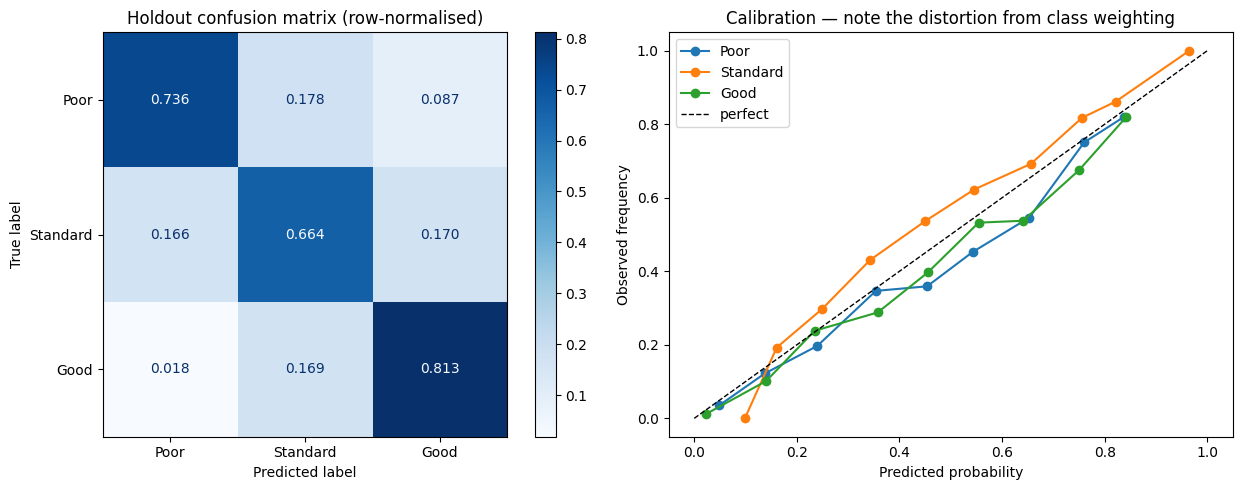

Class weighting deliberately trades calibration for balanced recall. These probabilities
rank well (see ROC-AUC) but are not P(class|x); any real decision rule would need
post-hoc recalibration on top.


In [30]:
final_proba = blend_ho
final_pred  = (final_proba * MULTS).argmax(1)

print("Per-row holdout report (cold-start regime):")
print(classification_report(y_holdout, final_pred, target_names=CLASS_NAMES, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_holdout, final_pred, normalize='true'),
                       display_labels=CLASS_NAMES).plot(cmap='Blues', ax=axes[0], values_format='.3f')
axes[0].set_title('Holdout confusion matrix (row-normalised)')

for c in range(3):
    pt, pp = calibration_curve((y_holdout == c).astype(int), final_proba[:, c], n_bins=10)
    axes[1].plot(pp, pt, marker='o', label=CLASS_NAMES[c])
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='perfect')
axes[1].set_xlabel('Predicted probability'); axes[1].set_ylabel('Observed frequency')
axes[1].set_title('Calibration — note the distortion from class weighting')
axes[1].legend()
plt.tight_layout(); plt.show()

print("Class weighting deliberately trades calibration for balanced recall. These probabilities")
print("rank well (see ROC-AUC) but are not P(class|x); any real decision rule would need")
print("post-hoc recalibration on top.")

## Explainability

SHAP on one fold's tuned LightGBM. Credit decisions have to be explainable, so this is not decoration
— it is the part that would matter most if this were a real model.


[  22.9 min total | +  0.0 min] SHAP explainability


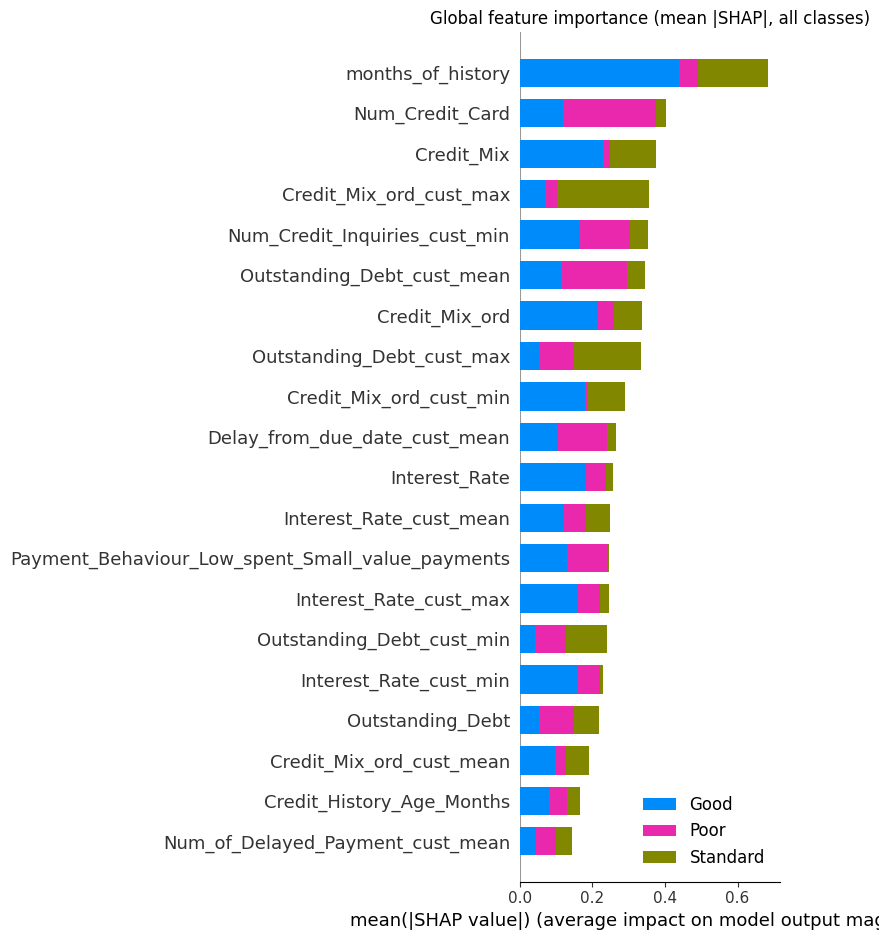

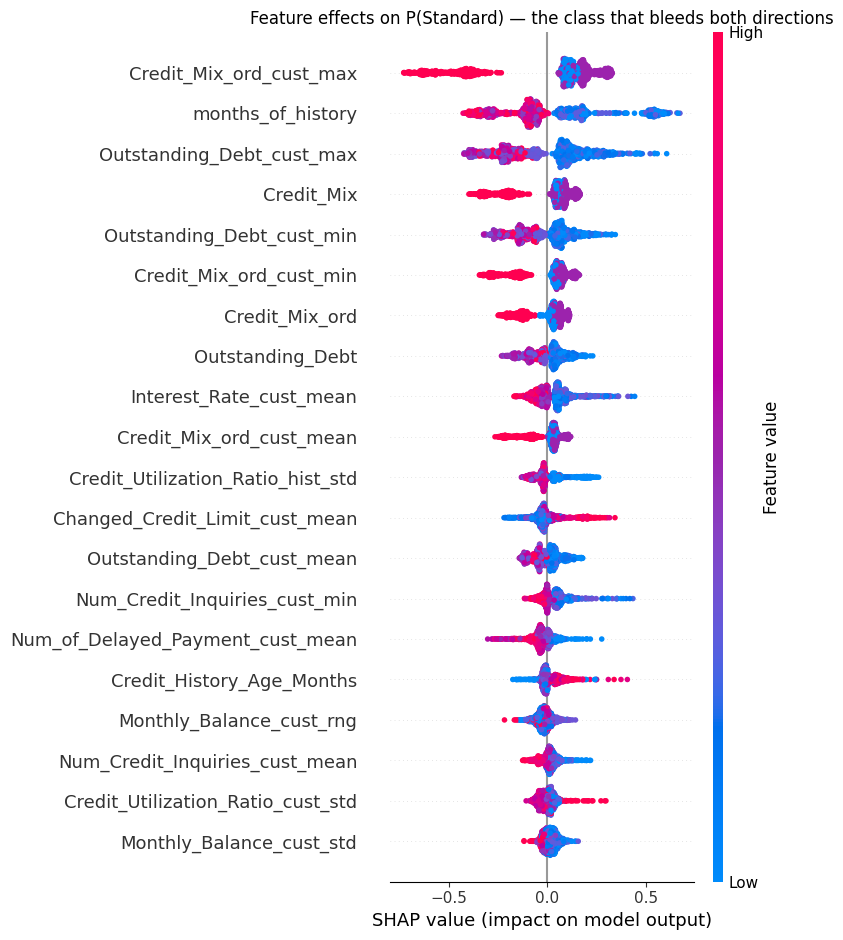

Top 20 features by mean |SHAP|:


months_of_history                                   0.2276
Num_Credit_Card                                     0.1344
Credit_Mix                                          0.1252
Credit_Mix_ord_cust_max                             0.1183
Num_Credit_Inquiries_cust_min                       0.1178
Outstanding_Debt_cust_mean                          0.1146
Credit_Mix_ord                                      0.1125
Outstanding_Debt_cust_max                           0.1110
Credit_Mix_ord_cust_min                             0.0967
Delay_from_due_date_cust_mean                       0.0880
Interest_Rate                                       0.0852
Interest_Rate_cust_mean                             0.0833
Payment_Behaviour_Low_spent_Small_value_payments    0.0823
Interest_Rate_cust_max                              0.0820
Outstanding_Debt_cust_min                           0.0801
Interest_Rate_cust_min                              0.0767
Outstanding_Debt                                    0.07

In [31]:
section("SHAP explainability")
import shap

shap_model = REG['LightGBM_tuned']['models'][0]
sample = X_holdout.sample(min(SHAP_SAMPLE, len(X_holdout)), random_state=SEED)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(sample)

# SHAP >= 0.45 returns a single (n, features, classes) array for multiclass; older versions
# return a list of per-class arrays. Normalise to a list so both work.
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

# Global importance across all three classes
shap.summary_plot(shap_values, sample, class_names=CLASS_NAMES, plot_type='bar', show=False)
plt.title('Global feature importance (mean |SHAP|, all classes)')
plt.tight_layout(); plt.savefig('/kaggle/working/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Directional detail for the hardest class -- Standard is where the errors concentrate
std_idx = CLASS_NAMES.index('Standard')
shap.summary_plot(shap_values[std_idx], sample, show=False, max_display=20)
plt.title("Feature effects on P(Standard) — the class that bleeds both directions")
plt.tight_layout(); plt.savefig('/kaggle/working/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs = np.abs(np.stack(shap_values)).mean(axis=(0, 1))
top = pd.Series(mean_abs, index=sample.columns).sort_values(ascending=False).head(20)
print("Top 20 features by mean |SHAP|:")
display(top.round(4))

## Artifacts, and a round-trip test that proves they work

The previous version pickled `shap_model` under the name `best_credit_score_model.pkl` — a different
object from the reported winner whenever the winner was not a tree model — and saved a scaler that
the saved model did not use. Worse, the pickle was unusable on its own, because the entire cleaning
and feature-engineering chain lived only in notebook cells.

What gets saved here is the whole scoring path: the fold models, the fitted preprocessing statistics,
the column order, the blend weights and the class multipliers. The cell after it reloads the bundle
and reproduces predictions from **raw** rows, asserting they match. An artifact that has not been
round-tripped is an assumption, not a deliverable.

In [32]:
import joblib

# Every blend member is saved, with the frame it expects and how to turn it into probabilities.
# The saved artifact must reproduce the *reported* blend exactly -- storing a convenient subset
# and renormalising would make the pickle silently disagree with the numbers above.
FRAME_OF = {'CatBoost': 'cat', 'CatBoost_tuned': 'cat'}
KIND_OF  = {'LightGBM_ordinal': 'ordinal'}

BUNDLE = {
    'families': {
        name: {'kind':   KIND_OF.get(name, 'multiclass'),
               'frame':  FRAME_OF.get(name, 'ohe'),
               'models': REG[name]['models']}
        for name in BLEND_MEMBERS
    },
    'blend_members': BLEND_MEMBERS,
    'blend_weights': best_w,
    'multipliers':   MULTS,
    'stats':         STATS,
    'ohe_columns':   OHE_COLUMNS,
    'cat_columns':   CAT_COLUMNS,
    'cat_features':  CAT_FEATURES,
    'class_names':   CLASS_NAMES,
    'use_full_window': USE_FULL_WINDOW,
}
joblib.dump(BUNDLE, '/kaggle/working/credit_score_bundle.pkl')

oof_table().to_csv('/kaggle/working/model_comparison_oof.csv')
final_df.to_csv('/kaggle/working/model_comparison_holdout.csv')
print("Saved: credit_score_bundle.pkl, model_comparison_oof.csv, "
      "model_comparison_holdout.csv, shap_summary.png")

Saved: credit_score_bundle.pkl, model_comparison_oof.csv, model_comparison_holdout.csv, shap_summary.png


In [33]:
def score_raw(raw_df, bundle):
    '''Raw customer-month rows -> class probabilities. The full production path.'''
    fe = transform(raw_df, bundle['stats'])
    X_o, X_c, _, g = encode(fe, bundle['ohe_columns'], bundle['cat_columns'])

    def family_proba(spec):
        X = X_c if spec['frame'] == 'cat' else X_o
        if spec['kind'] == 'ordinal':
            folds = []
            for pair in spec['models']:
                p1, p2 = (m.predict_proba(X)[:, 1] for m in pair)
                out = np.clip(np.column_stack([1 - p1, p1 - p2, p2]), 1e-6, None)
                folds.append(out / out.sum(axis=1, keepdims=True))
            return np.mean(folds, axis=0)
        return np.mean([m.predict_proba(X) for m in spec['models']], axis=0)

    proba = sum(w * family_proba(bundle['families'][name])
                for name, w in zip(bundle['blend_members'], bundle['blend_weights']))
    return proba, g


reloaded = joblib.load('/kaggle/working/credit_score_bundle.pkl')

# whole customers only -- panel features need a customer's full history
probe_ids = raw_holdout['Customer_ID'].drop_duplicates().head(50)
probe_raw = raw_holdout[raw_holdout['Customer_ID'].isin(probe_ids)].reset_index(drop=True)

proba_rt, g_rt = score_raw(probe_raw, reloaded)
pred_rt = (proba_rt * reloaded['multipliers']).argmax(1)

ref = pd.DataFrame({'cid': groups_holdout, 'pred': (blend_ho * MULTS).argmax(1)})
ref = ref[ref['cid'].isin(set(probe_ids))]
match = (pd.DataFrame({'cid': g_rt, 'pred': pred_rt}).sort_values('cid')['pred'].values ==
         ref.sort_values('cid')['pred'].values)

print(f"Round-trip: {len(probe_raw)} raw rows, {len(probe_ids)} customers")
print(f"Predictions matching the in-memory blend: {match.mean():.1%}")
assert match.mean() > 0.99, "Round-trip mismatch -- the saved bundle does not reproduce the model."
print("Bundle verified: raw CSV rows -> predictions, end to end.")

Round-trip: 400 raw rows, 50 customers
Predictions matching the in-memory blend: 100.0%
Bundle verified: raw CSV rows -> predictions, end to end.


In [34]:
agg = final['Blend + thresholds + per-cust (rejected)']
headline = final[FINAL_LABEL]   # the Blend row -- thresholding has not cleared its own noise floor

lines = [
    "================ SUMMARY (paste into README) ================",
    f"Dataset    : ParisRohan Credit Score Classification (synthetic; 100K rows, {n_cust:,} customers x 8 months)",
    "Task       : 3-class credit-score bucket (Poor / Standard / Good)",
    "Validation : GroupShuffleSplit + StratifiedGroupKFold on Customer_ID; preprocessing fit on train only",
    "Selection  : model, blend weights and thresholds all chosen on OOF; holdout scored once",
    "",
    "HOLDOUT RESULTS",
    f"  Best single model ({best_single}): macro-F1 {final['Best single model']['macro_f1']:.4f}",
    f"  Weighted blend [FINAL]           : macro-F1 {headline['macro_f1']:.4f} | "
    f"AUC {headline['roc_auc_ovr']:.4f} | acc {headline['accuracy']:.4f}",
    f"  Threshold tuning                 : below the {MIN_THRESHOLD_GAIN} OOF noise floor on this run "
    f"-- not applied ({THRESH_LABEL.split(' (')[0]})"
    if threshold_gain < MIN_THRESHOLD_GAIN else
    f"  + tuned thresholds  [cold-start] : macro-F1 {final[THRESH_LABEL]['macro_f1']:.4f}",
    f"  + customer agg  [REJECTED, -{headline['macro_f1'] - agg['macro_f1']:.4f}] : "
    f"macro-F1 {agg['macro_f1']:.4f} -- label is not constant per customer",
    "",
    f"  Leaky random-row split, for contrast: macro-F1 {rand_f1:.4f} "
    f"(inflated by {rand_f1 - grp_f1:+.4f})",
    "",
    "CAVEATS, STATED UP FRONT",
    "  - The dataset is synthetic: labels are rule-generated and the dirt is injected.",
    "    This is a methodology showcase, not a deployable credit model.",
    "  - Customer-level aggregation was TESTED AND REJECTED: only 41.7% of customers",
    "    carry one label across their months, so averaging destroys real variation.",
    "  - Class weighting trades calibration for balanced recall; probabilities rank well",
    "    but are not P(class|x) without recalibration.",
    "=============================================================",
]
print("\n".join(lines))

================ SUMMARY (paste into README) ================
Dataset    : ParisRohan Credit Score Classification (synthetic; 100K rows, 12,500 customers x 8 months)
Task       : 3-class credit-score bucket (Poor / Standard / Good)
Validation : GroupShuffleSplit + StratifiedGroupKFold on Customer_ID; preprocessing fit on train only
Selection  : model, blend weights and thresholds all chosen on OOF; holdout scored once

HOLDOUT RESULTS
  Best single model (LightGBM_tuned): macro-F1 0.7005
  Weighted blend [FINAL]           : macro-F1 0.7046 | AUC 0.8715 | acc 0.7118
  Threshold tuning                 : below the 0.001 OOF noise floor on this run -- not applied (Blend + thresholds)
  + customer agg  [REJECTED, -0.0056] : macro-F1 0.6989 -- label is not constant per customer

  Leaky random-row split, for contrast: macro-F1 0.8171 (inflated by +0.1197)

CAVEATS, STATED UP FRONT
  - The dataset is synthetic: labels are rule-generated and the dirt is injected.
    This is a methodology show